In [ ]:
import os
print(os.getcwd())
print(sorted(os.listdir()))

/content
['.config', 'sample_data']
Mounted at /content/drive
['NEDL_Bollinger_Bands_.ipynb', 'NEDL_Efficient_Portfolio_Frontier_.ipynb', 'NEDL_Garch_Python_.ipynb', 'NEDL_Technical_trading_MACD_.ipynb', 'NEDL_Technical_trading_RSI.ipynb', 'NEDL_Technical_trading_RSI_.ipynb', 'NEWLSTM_.ipynb', '__pycache__', 'stable-diffusion.ipynb', 'test_rut.ipynb', 'test_spx.ipynb', 'test_t (1).ipynb', 'test_t.ipynb', 'test_ta_packages.ipynb', 'tools']


In [ ]:
# Google Colab

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/github/quant_dev/notebooks')
print(sorted(os.listdir()))

In [ ]:
# Add the parent directory to the sys.path
sys.path.append(
    os.path.dirname(
        os.path.dirname(os.path.abspath(__file__))
        if "__file__" in globals().keys()
        else os.getcwd()
    )
)

In [ ]:
from tools.basic import *

bold text# KO analysis

In [ ]:
start_date = '2016-01-01'
end_date = dt.datetime.strftime(dt.datetime.today(), "%Y-%m-%d")
trade_d = 250

In [ ]:
# Note
# Dow Jones Industrial Average (DJIA) → ^DJI
# S&P 500 Index → ^GSPC
# Nasdaq Composite Index → ^IXIC
# Russell 2000 Index → ^RUT

stock = 'KO'
data = yf.download(stock, start_date, end_date)

/tmp/ipython-input-1388946946.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


In [ ]:
for d in [1, 2, 3, 4, 5, 10, 250]:
  if d == 1:
    data["PCT Change 1"] = data["Close"].pct_change()
    data["PCT Change 1 Av"] = data["PCT Change 1"].rolling(trade_d).mean()
    data["PCT Change 1 STD"] = data["PCT Change 1"].rolling(trade_d).std()

  else:
    data[f"PCT Change {d}"] = data["PCT Change 1"].rolling(d).sum()
    data[f"PCT Change {d} Av"] = data[f"PCT Change {d}"].rolling(trade_d).mean()
    data[f"PCT Change {d} STD"] = data[f"PCT Change {d}"].rolling(trade_d).std()

  data["PCT Change Annualized"] = data["PCT Change 1"].rolling(trade_d).sum()
  data["PCT Change Annualized STD"] = data["PCT Change 1 STD"] * trade_d ** 0.5

pct_change = data["PCT Change 1"]


In [ ]:
data.tail()

Price,Close,High,Low,Open,Volume,PCT Change 1,PCT Change 1 Av,PCT Change 1 STD,PCT Change Annualized,PCT Change Annualized STD,...,PCT Change 4 STD,PCT Change 5,PCT Change 5 Av,PCT Change 5 STD,PCT Change 10,PCT Change 10 Av,PCT Change 10 STD,PCT Change 250,PCT Change 250 Av,PCT Change 250 STD
Ticker,KO,KO,KO,KO,KO,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-03,66.650002,66.989998,66.040001,66.099998,12249200,0.008321,-0.000050,0.010743,-0.012458,0.169865,...,0.021037,0.014948,-0.000573,0.023200,0.003519,-0.001237,0.031782,-0.012458,0.133402,0.081441
2025-10-06,66.099998,66.500000,65.839996,66.489998,14333300,-0.008252,-0.000063,0.010751,-0.015747,0.169992,...,0.020985,0.001062,-0.000478,0.023158,-0.001421,-0.001160,0.031758,-0.015747,0.132074,0.081154
2025-10-07,66.790001,67.260002,65.870003,66.220001,13328300,0.010439,0.000045,0.010721,0.011223,0.169507,...,0.020847,0.007261,-0.000288,0.023025,0.001466,-0.001001,0.031670,0.011223,0.130900,0.080769
2025-10-08,66.120003,66.870003,66.059998,66.669998,12606700,-0.010031,-0.000005,0.010738,-0.001272,0.169789,...,0.020783,-0.009707,-0.000184,0.022923,-0.004668,-0.000898,0.031616,-0.001272,0.129754,0.080602
2025-10-09,66.370003,66.800003,66.120003,66.290001,12705200,0.003781,-0.000013,0.010735,-0.003128,0.169737,...,0.020768,0.004257,-0.000086,0.022889,0.006186,-0.000767,0.031578,-0.003128,0.128554,0.080337


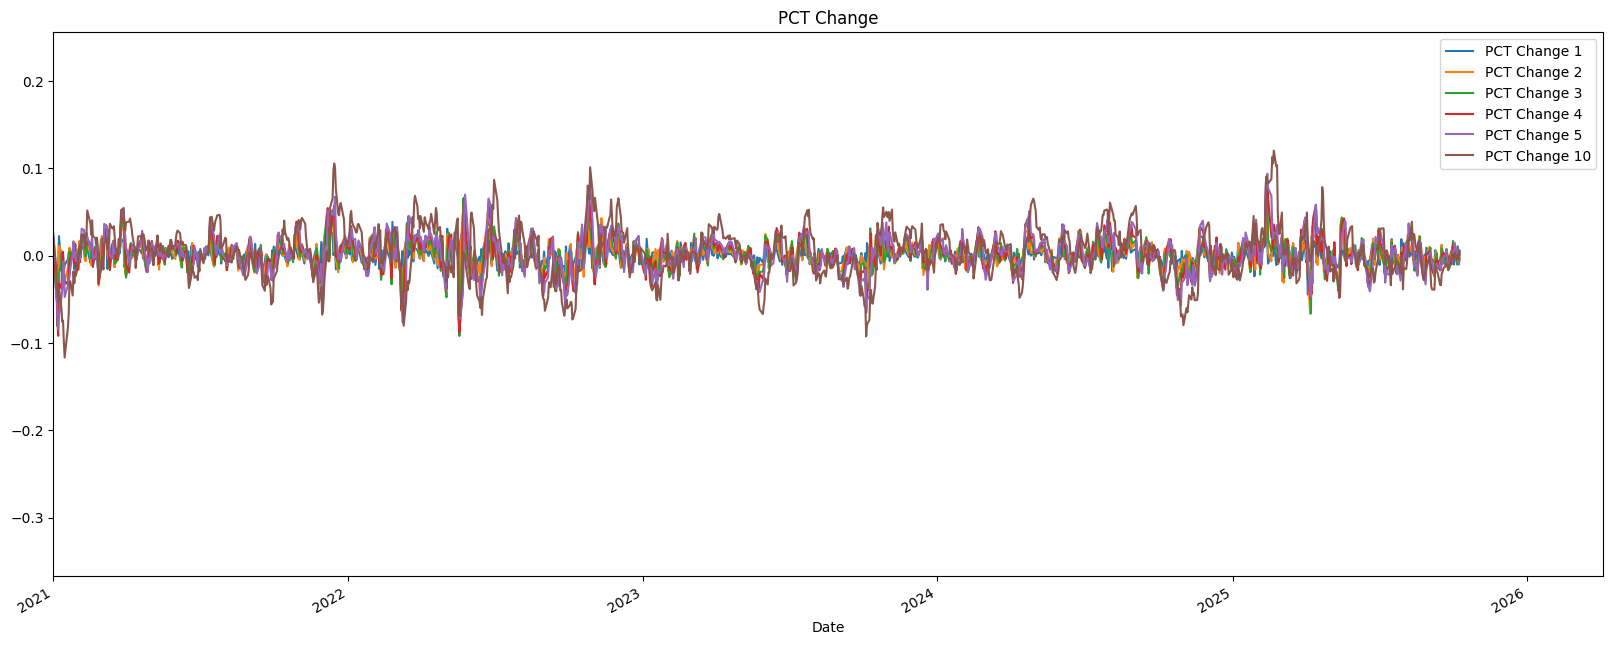

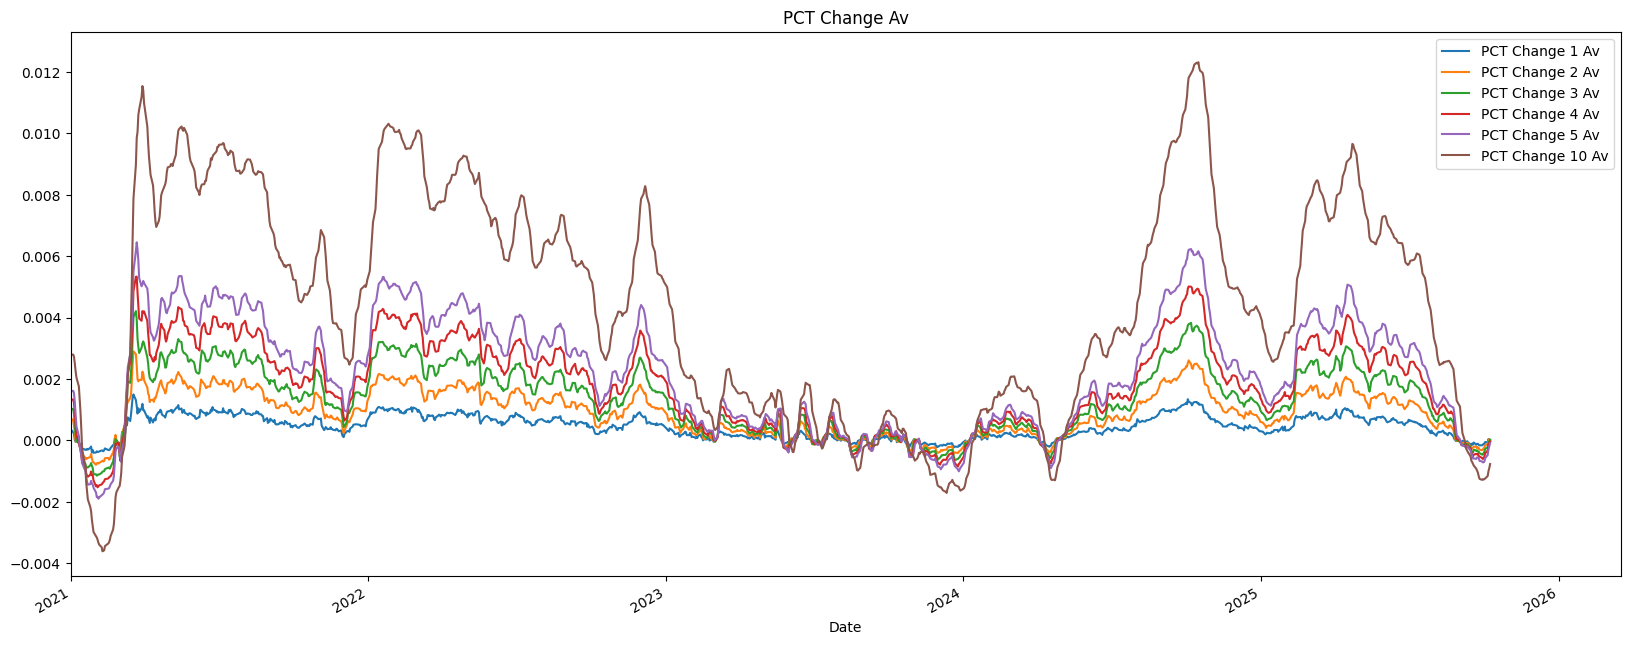

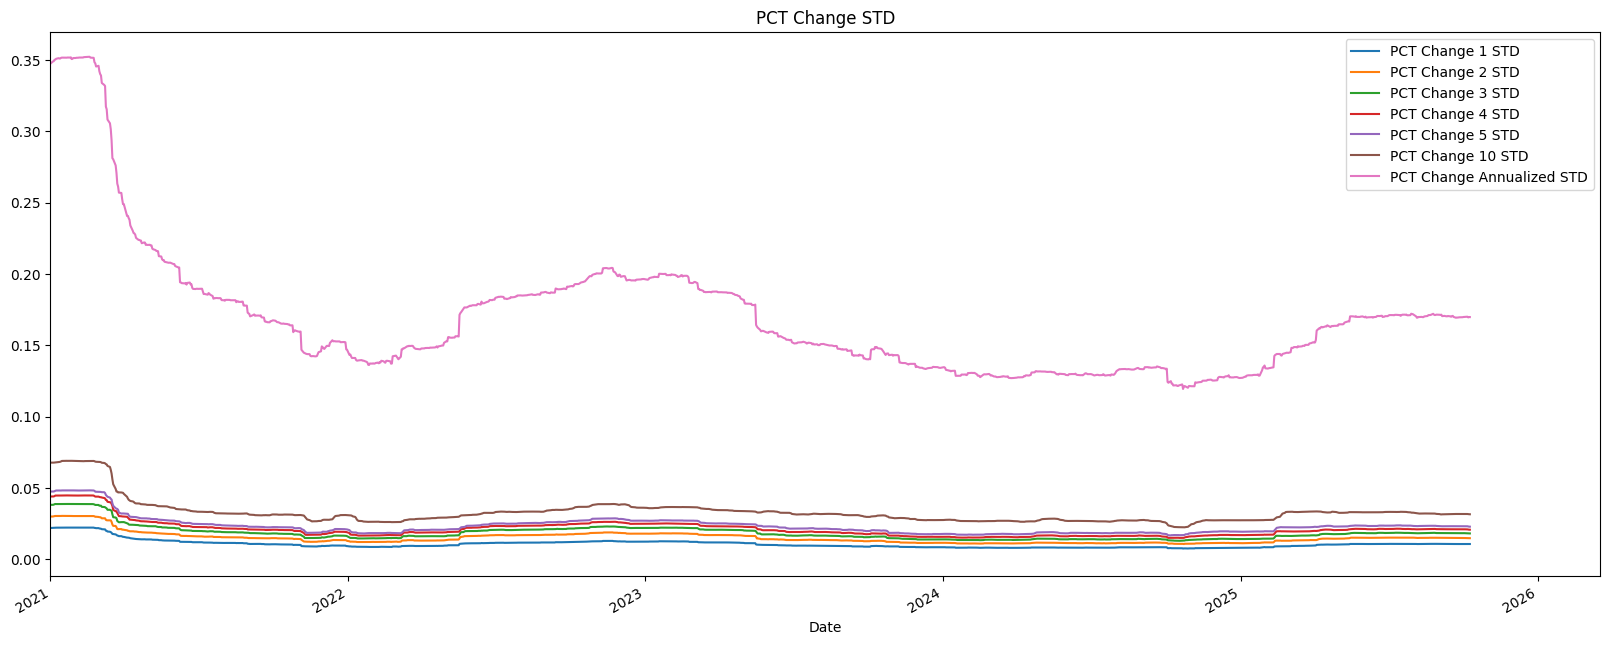

In [ ]:
# @ Plots
from matplotlib import pyplot as plt
plt.figure(figsize=(20, 8))
for d in [1, 2, 3, 4, 5, 10]:
  data[f"PCT Change {d}"].plot(kind='line', label=f"PCT Change {d}")

plt.xlim(dt.datetime(2021,1,1),)
plt.title("PCT Change")
plt.legend()
plt.show()

plt.figure(figsize=(20, 8))
for d in [1, 2, 3, 4, 5, 10]:
  data[f"PCT Change {d} Av"].plot(kind='line', label=f"PCT Change {d} Av")

plt.xlim(dt.datetime(2021,1,1),)
plt.title("PCT Change Av")
plt.legend()
plt.show()

plt.figure(figsize=(20, 8))
for d in [1, 2, 3, 4, 5, 10]:
  data[f"PCT Change {d} STD"].plot(kind='line', label=f"PCT Change {d} STD")

data["PCT Change Annualized STD"].plot(kind='line', label="PCT Change Annualized STD")

plt.title("PCT Change STD")
plt.xlim(dt.datetime(2021,1,1),)
plt.legend()
plt.show()

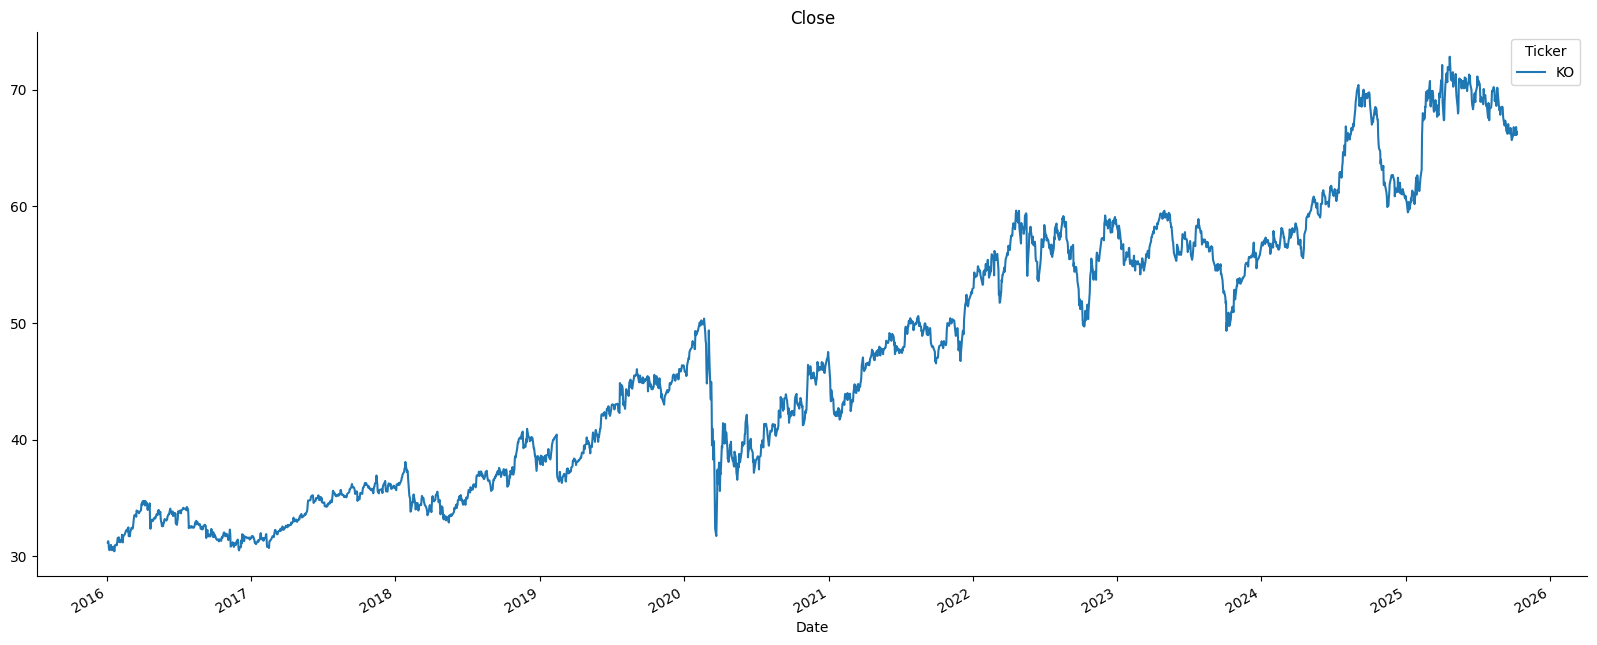

In [ ]:
# @title Close

from matplotlib import pyplot as plt
data['Close'].plot(kind='line', figsize=(20, 8), title='Close')
plt.gca().spines[['top', 'right']].set_visible(False)

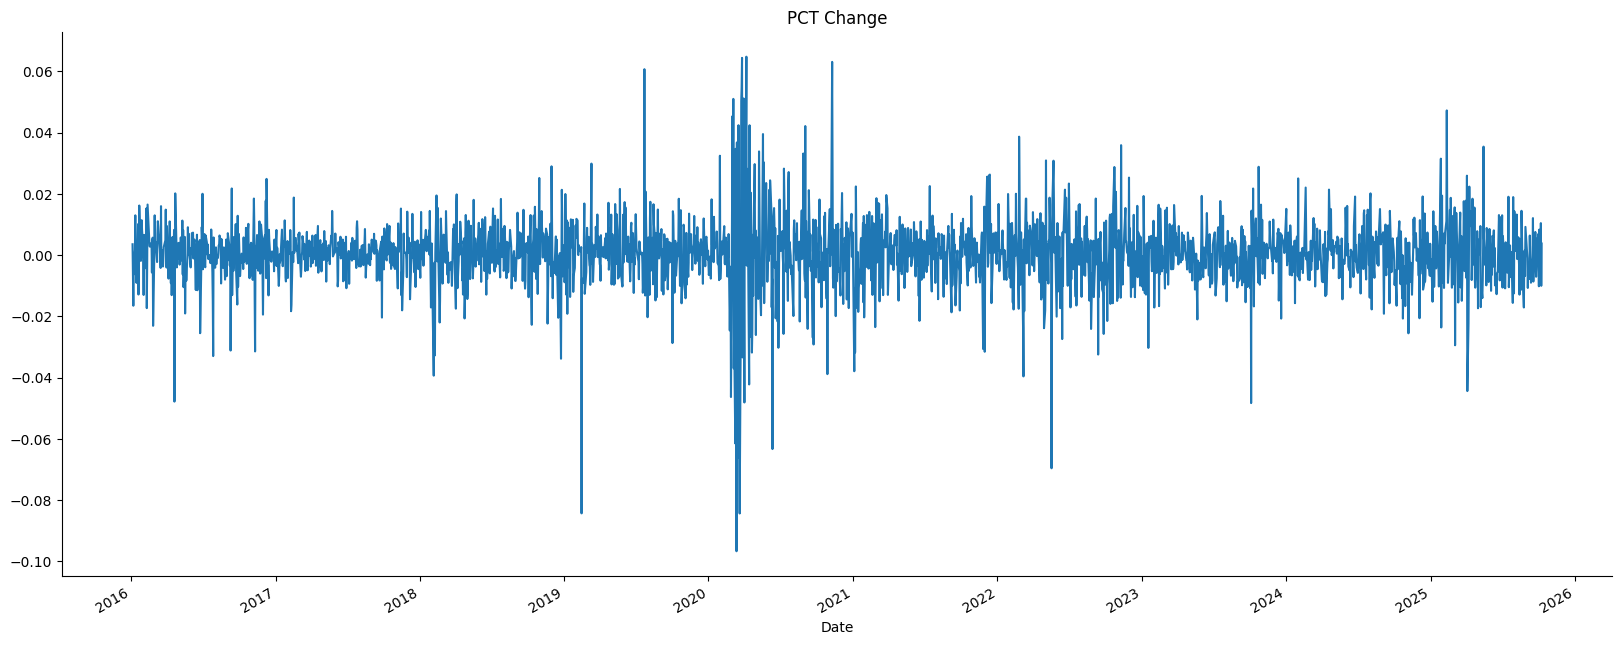

In [ ]:
# @title PCT Change

from matplotlib import pyplot as plt
data['PCT Change 1'].plot(kind='line', figsize=(20, 8), title='PCT Change')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
print(f"Min pct change: {pct_change.min()}")
print(f"Max pct change: {pct_change.max()}")

Min pct change: -0.09672485352403593
Max pct change: 0.06479544503290735


# Vol and mean

## Annualized

In [ ]:
data["PCT Change Annualized"].iloc[-1]

np.float64(-0.0031281005008827467)

In [ ]:
data["PCT Change Annualized STD"].iloc[-1]

np.float64(0.1697369167012392)

## Daily

In [ ]:
data.iloc[-1]

,,2025-10-09
Price,Ticker,
Close,KO,6.637000e+01
High,KO,6.680000e+01
Low,KO,6.612000e+01
Open,KO,6.629000e+01
Volume,KO,1.270520e+07
PCT Change 1,,3.781004e-03
PCT Change 1 Av,,-1.251240e-05
PCT Change 1 STD,,1.073511e-02
PCT Change Annualized,,-3.128101e-03


In [ ]:
sd = data["PCT Change 1 STD"].iloc[-1]
# sd = pct_change[-250:].std()
sd

np.float64(0.010735105195803797)

In [ ]:
mu = data["PCT Change 1 Av"].iloc[-1]
# mu = pct_change[-250:].mean()
mu

np.float64(-1.2512402003530987e-05)

# Historical analysis

In [ ]:
sd_his = data["PCT Change 1"].dropna().std()
# sd_his = pct_change.dropna().std()
sd_his

0.011396941627346635

In [ ]:
# Threshold daily volatility
sd_th = 0.01

In [ ]:
df_his = pd.DataFrame()

for sd in [0.05, 0.045, 0.04, 0.035, 0.03, 0.025, 0.02, 0.015, 0.01, 0.005, 0.002, 0.001, 0.0001]:
  for n_y in [2,5]:
    for n_d in [1,2,3,4,5,10,20,30]:
      df = consecutive_analysis(pct_change, sd, n_d, n_y, return_output=True)
      df_his = pd.concat([df_his, df])
    print()

df_his.reset_index(drop=True, inplace=True)

Consecutive change of above 5.00% for 1 days in the last 2 years:
Probability 0.0% 
Consecutive change of below 5.00% for 1 days in the last 2 years:
Probability 0.0% 
Cumulative change of above 5.00% in 1 days in the last 2 years:
Probability 0.0% 
Cumulative change of below 5.00% in 1 days in the last 2 years:
Probability 0.0% 
Consecutive change of above 5.00% for 2 days in the last 2 years:
Probability 0.0% 
Consecutive change of below 5.00% for 2 days in the last 2 years:
Probability 0.0% 
Cumulative change of above 5.00% in 2 days in the last 2 years:
Probability 0.4% Last occured on 2025-02-12
Cumulative change of below 5.00% in 2 days in the last 2 years:
Probability 0.2% Last occured on 2025-04-07
Consecutive change of above 5.00% for 3 days in the last 2 years:
Probability 0.0% 
Consecutive change of below 5.00% for 3 days in the last 2 years:
Probability 0.0% 
Cumulative change of above 5.00% in 3 days in the last 2 years:
Probability 0.6% Last occured on 2025-02-13
Cumulati

In [ ]:
data.tail()

Price,Close,High,Low,Open,Volume,PCT Change 1,PCT Change 1 Av,PCT Change 1 STD,PCT Change Annualized,PCT Change Annualized STD,...,PCT Change 4 STD,PCT Change 5,PCT Change 5 Av,PCT Change 5 STD,PCT Change 10,PCT Change 10 Av,PCT Change 10 STD,PCT Change 250,PCT Change 250 Av,PCT Change 250 STD
Ticker,KO,KO,KO,KO,KO,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-03,66.650002,66.989998,66.040001,66.099998,12249200,0.008321,-0.000050,0.010743,-0.012458,0.169865,...,0.021037,0.014948,-0.000573,0.023200,0.003519,-0.001237,0.031782,-0.012458,0.133402,0.081441
2025-10-06,66.099998,66.500000,65.839996,66.489998,14333300,-0.008252,-0.000063,0.010751,-0.015747,0.169992,...,0.020985,0.001062,-0.000478,0.023158,-0.001421,-0.001160,0.031758,-0.015747,0.132074,0.081154
2025-10-07,66.790001,67.260002,65.870003,66.220001,13328300,0.010439,0.000045,0.010721,0.011223,0.169507,...,0.020847,0.007261,-0.000288,0.023025,0.001466,-0.001001,0.031670,0.011223,0.130900,0.080769
2025-10-08,66.120003,66.870003,66.059998,66.669998,12606700,-0.010031,-0.000005,0.010738,-0.001272,0.169789,...,0.020783,-0.009707,-0.000184,0.022923,-0.004668,-0.000898,0.031616,-0.001272,0.129754,0.080602
2025-10-09,66.370003,66.800003,66.120003,66.290001,12705200,0.003781,-0.000013,0.010735,-0.003128,0.169737,...,0.020768,0.004257,-0.000086,0.022889,0.006186,-0.000767,0.031578,-0.003128,0.128554,0.080337


In [ ]:
# 1 Day
df = df_his.query("n_days == 1").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
0,consecutive,above,5.00%,1,2,0.000,
1,consecutive,below,5.00%,1,2,0.000,
2,cumulative,above,5.00%,1,2,0.000,
3,cumulative,below,5.00%,1,2,0.000,
32,consecutive,above,5.00%,1,5,0.001,Last occured on 2020-11-09
...,...,...,...,...,...,...,...
451,cumulative,below,1.50%,1,2,0.042,Last occured on 2025-08-25
480,consecutive,above,1.50%,1,5,0.062,Last occured on 2025-07-29
481,consecutive,below,1.50%,1,5,0.054,Last occured on 2025-08-25
482,cumulative,above,1.50%,1,5,0.062,Last occured on 2025-07-29


In [ ]:
# 2 Day
df = df_his.query("n_days == 2").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
4,consecutive,above,5.00%,2,2,0.000,
5,consecutive,below,5.00%,2,2,0.000,
6,cumulative,above,5.00%,2,2,0.004,Last occured on 2025-02-12
7,cumulative,below,5.00%,2,2,0.002,Last occured on 2025-04-07
36,consecutive,above,5.00%,2,5,0.000,
...,...,...,...,...,...,...,...
549,consecutive,below,1.00%,2,5,0.011,Last occured on 2025-07-09
580,consecutive,above,0.50%,2,2,0.084,Last occured on 2025-08-20
581,consecutive,below,0.50%,2,2,0.060,Last occured on 2025-08-25
612,consecutive,above,0.50%,2,5,0.084,Last occured on 2025-08-20


In [ ]:
# 3 Day
df = df_his.query("n_days == 3").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
8,consecutive,above,5.00%,3,2,0.000,
9,consecutive,below,5.00%,3,2,0.000,
10,cumulative,above,5.00%,3,2,0.006,Last occured on 2025-02-13
11,cumulative,below,5.00%,3,2,0.002,Last occured on 2025-04-08
40,consecutive,above,5.00%,3,5,0.000,
...,...,...,...,...,...,...,...
681,consecutive,below,0.20%,3,5,0.054,Last occured on 2025-09-26
713,consecutive,below,0.10%,3,2,0.074,Last occured on 2025-09-26
745,consecutive,below,0.10%,3,5,0.074,Last occured on 2025-09-26
777,consecutive,below,0.01%,3,2,0.092,Last occured on 2025-09-26


In [ ]:
# 4 Day
df = df_his.query("n_days == 4").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
12,consecutive,above,5.00%,4,2,0.000,
13,consecutive,below,5.00%,4,2,0.000,
14,cumulative,above,5.00%,4,2,0.010,Last occured on 2025-04-14
15,cumulative,below,5.00%,4,2,0.000,
44,consecutive,above,5.00%,4,5,0.000,
...,...,...,...,...,...,...,...
749,consecutive,below,0.10%,4,5,0.027,Last occured on 2025-09-08
780,consecutive,above,0.01%,4,2,0.080,Last occured on 2025-08-07
781,consecutive,below,0.01%,4,2,0.034,Last occured on 2025-09-15
812,consecutive,above,0.01%,4,5,0.072,Last occured on 2025-08-07


In [ ]:
# 5 Day
df = df_his.query("n_days == 5").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
16,consecutive,above,5.00%,5,2,0.000,
17,consecutive,below,5.00%,5,2,0.000,
18,cumulative,above,5.00%,5,2,0.014,Last occured on 2025-04-14
19,cumulative,below,5.00%,5,2,0.004,Last occured on 2024-10-29
48,consecutive,above,5.00%,5,5,0.000,
...,...,...,...,...,...,...,...
753,consecutive,below,0.10%,5,5,0.009,Last occured on 2025-06-20
784,consecutive,above,0.01%,5,2,0.048,Last occured on 2025-08-07
785,consecutive,below,0.01%,5,2,0.008,Last occured on 2025-06-20
816,consecutive,above,0.01%,5,5,0.036,Last occured on 2025-08-07


In [ ]:
# Two weeks
df = df_his.query("n_days == 10").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
20,consecutive,above,5.00%,10,2,0.000,
21,consecutive,below,5.00%,10,2,0.000,
22,cumulative,above,5.00%,10,2,0.052,Last occured on 2025-04-23
23,cumulative,below,5.00%,10,2,0.024,Last occured on 2024-11-18
52,consecutive,above,5.00%,10,5,0.000,
...,...,...,...,...,...,...,...
757,consecutive,below,0.10%,10,5,0.000,
788,consecutive,above,0.01%,10,2,0.000,
789,consecutive,below,0.01%,10,2,0.000,
820,consecutive,above,0.01%,10,5,0.000,


In [ ]:
# 1 month
df = df_his.query("n_days == 20").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
24,consecutive,above,5.00%,20,2,0.000,
25,consecutive,below,5.00%,20,2,0.000,
27,cumulative,below,5.00%,20,2,0.046,Last occured on 2025-09-19
56,consecutive,above,5.00%,20,5,0.000,
57,consecutive,below,5.00%,20,5,0.000,
59,cumulative,below,5.00%,20,5,0.095,Last occured on 2025-09-19
88,consecutive,above,4.50%,20,2,0.000,
89,consecutive,below,4.50%,20,2,0.000,
91,cumulative,below,4.50%,20,2,0.054,Last occured on 2025-09-22
120,consecutive,above,4.50%,20,5,0.000,


In [ ]:
# 1.5 Months
df = df_his.query("n_days == 30").copy()
df["prob"] = df["prob"].str.rstrip('%').astype('float') / 100
df.loc[df["prob"] < 0.1]

,change_type,change,up_dn,n_days,n_years,prob,last_occured
28,consecutive,above,5.00%,30,2,0.000,
29,consecutive,below,5.00%,30,2,0.000,
31,cumulative,below,5.00%,30,2,0.078,Last occured on 2025-10-06
60,consecutive,above,5.00%,30,5,0.000,
61,consecutive,below,5.00%,30,5,0.000,
92,consecutive,above,4.50%,30,2,0.000,
93,consecutive,below,4.50%,30,2,0.000,
95,cumulative,below,4.50%,30,2,0.088,Last occured on 2025-10-06
124,consecutive,above,4.50%,30,5,0.000,
125,consecutive,below,4.50%,30,5,0.000,
